In [36]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import RemoveMessage, HumanMessage
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

In [37]:
load_dotenv()

True

In [38]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [39]:
class summarystate(MessagesState):
    summary: str

In [40]:
def chat_node(state: summarystate):
    messages = []
    
    # we will check for the messages in state
    if state['summary']:
        messages.append({
            "role" : "system",
            "content" : f"Conversation Summary {state['summary']}"
        })
        
    # then we will attach this in the state
    messages.extend(state["messages"])
    
    print(messages)
    
    response = LLM.invoke(messages)
    return {"messages" : [response]}

In [41]:
# now building our summarizer node
def summarry_node(state: summarystate):
    
    # getting the summary from the state
    existing_summary = state['summary']
    
    #building the prompt 
    if existing_summary:
        prompt = (f"existing summary\n {state['summary']}"
        "extend the summary using the new conversation above")
    else:
        prompt = "Summarize the above conversation"
        
    # combining both 
    message_for_summary = state['messages'] + [HumanMessage(content=prompt)] 
    
    # giving this message to llm(summary generation)
    response = LLM.invoke(message_for_summary)
    
    # performing deletion for the rest and keeping just 2
    message_for_deletion = state['messages'][:-2]
    
    # now returining 2 things 
    return {
        "Summary" : response.content,
        "Messages" : [RemoveMessage(id=m.id) for m in message_for_deletion]
    }

In [42]:
def should_summarize(state: summarystate):
    return len(state['messages'])>6

In [43]:
#building the node
graph = StateGraph(summarystate)

graph.add_node("chat_node", chat_node)
graph.add_node("summarry_node", summarry_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", should_summarize,{True: "summarry_node", False: "__end__"})
graph.add_edge("summarry_node", END)


In [44]:
#implementing checkpointer
memory = InMemorySaver()
STM_summarize = graph.compile(checkpointer=memory)


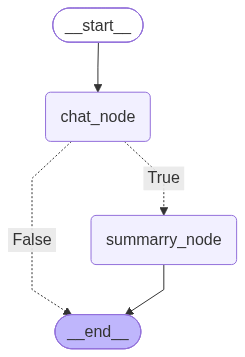

In [45]:
from IPython.display import Image
Image(STM_summarize.get_graph().draw_mermaid_png())

In [46]:
config = {"configurable": {"thread_id": "t1"}}

In [47]:
# gives the current version of the state
def show_state():
    snap = STM_summarize.get_state(config)
    vals = snap.values

    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")

    for m in vals.get("messages", []):
        print(" -", type(m).__name__, ":", m.content[:80])

In [48]:
out = STM_summarize.invoke({"messages": [HumanMessage(content="quantum Physics")], 'summary' : ""}, config=config)
print(out)
show_state()

[HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='d38eee25-4260-45df-91be-829560055533')]
{'messages': [HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='d38eee25-4260-45df-91be-829560055533'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atomic and sub‑atomic levels. Its predictions differ dramatically from those of classical physics and have given rise to a whole new way of thinking about the nature of reality.\n\nBelow is a compact guide to the most important ideas, experiments, and applications. Let me know if you’d like to dive deeper into any particular topic!\n\n---\n\n## 1. Core Principles\n\n| Principle | What It Says | Key Equation / Concept |\n|-----------|--------------|------------------------|\n| **Wave‑Particle Duality** | Particles (e.g., electrons, photons) exhibit both

In [49]:
out = STM_summarize.invoke({"messages": [HumanMessage(content="how albert einstine related to this")]}, config = config)
print(out)
show_state()

[HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='d38eee25-4260-45df-91be-829560055533'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atomic and sub‑atomic levels. Its predictions differ dramatically from those of classical physics and have given rise to a whole new way of thinking about the nature of reality.\n\nBelow is a compact guide to the most important ideas, experiments, and applications. Let me know if you’d like to dive deeper into any particular topic!\n\n---\n\n## 1. Core Principles\n\n| Principle | What It Says | Key Equation / Concept |\n|-----------|--------------|------------------------|\n| **Wave‑Particle Duality** | Particles (e.g., electrons, photons) exhibit both wave‑like and particle‑like properties. | de\u202fBroglie wavelength λ = h/p (h = Planck’s constant, p = momentum). |\n| **Superposition** | 

In [50]:
out = STM_summarize.invoke({"messages": [HumanMessage(content=" give some works of einstine")]}, config=config)
print(out)
show_state()

[HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='d38eee25-4260-45df-91be-829560055533'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atomic and sub‑atomic levels. Its predictions differ dramatically from those of classical physics and have given rise to a whole new way of thinking about the nature of reality.\n\nBelow is a compact guide to the most important ideas, experiments, and applications. Let me know if you’d like to dive deeper into any particular topic!\n\n---\n\n## 1. Core Principles\n\n| Principle | What It Says | Key Equation / Concept |\n|-----------|--------------|------------------------|\n| **Wave‑Particle Duality** | Particles (e.g., electrons, photons) exhibit both wave‑like and particle‑like properties. | de\u202fBroglie wavelength λ = h/p (h = Planck’s constant, p = momentum). |\n| **Superposition** | 

In [51]:
out = STM_summarize.invoke({"messages" : [HumanMessage(content="can you summarize his work throught his lifetime")]}, config=config)

[HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='d38eee25-4260-45df-91be-829560055533'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atomic and sub‑atomic levels. Its predictions differ dramatically from those of classical physics and have given rise to a whole new way of thinking about the nature of reality.\n\nBelow is a compact guide to the most important ideas, experiments, and applications. Let me know if you’d like to dive deeper into any particular topic!\n\n---\n\n## 1. Core Principles\n\n| Principle | What It Says | Key Equation / Concept |\n|-----------|--------------|------------------------|\n| **Wave‑Particle Duality** | Particles (e.g., electrons, photons) exhibit both wave‑like and particle‑like properties. | de\u202fBroglie wavelength λ = h/p (h = Planck’s constant, p = momentum). |\n| **Superposition** | 

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01jrmmana9f02amgrrctc566cg` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 9726, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}